# Phase 4: Advanced Statistics & Feature Engineering
Áp dụng Feature Engineering ngay trong các câu lệnh SQL siêu việt của DuckDB (ví dụ: công thức lượng giác Haversine tính khoảng cách tọa độ GPS) kết hợp với các thuật toán thống kê nâng cao.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..')) if current_dir.endswith('notebooks') else current_dir
if project_root not in sys.path:
    sys.path.append(project_root)

from src.stat_tester import StatTester
tester = StatTester(os.path.join(project_root, 'dataraw'), os.path.join(project_root, 'dataclean'))

### Khảo sát Nâng cao cho Thành phố Chicago (Divvy Bike)
Bạn có thể thay `city = 'citibike'` để khảo sát cho New York.


=== KIỂM ĐỊNH CHI-SQUARE: HÀNH TRÌNH KHÉP KÍN (DIVVY) ===
Ma trận tần số (Contingency Table):
is_circular_trip        0       1
member_casual                    
casual            1736298  306118
member            3438636  362401

- Tỷ lệ Hành trình khép kín của Casual: 14.99%
- Tỷ lệ Hành trình khép kín của Member: 9.53%

- Chi-Square statistic: 39001.79
- p-value: 0.0
=> KẾT LUẬN: Bác bỏ H0. Có sự khác biệt có ý nghĩa thống kê về tỷ lệ trả xe tại chỗ giữa 2 nhóm.
   Insight: Casual users thường thuê dạo chơi (trả chỗ cũ), trong khi Member đi làm (từ A đến B).

=== KIỂM ĐỊNH MANN-WHITNEY: VẬN TỐC DI CHUYỂN (DIVVY) ===
- Vận tốc trung bình Casual: 10.56 km/h
- Vận tốc trung bình Member: 12.70 km/h

- Mann-Whitney U statistic: 367252376.0
- p-value: 0.0
=> KẾT LUẬN: Thành viên (Member) có vận tốc đi xe trung bình nhanh hơn đáng kể so với Khách vãng lai (Casual).
   Insight: Chứng minh thói quen đi làm (nhanh, gấp) vs đi chơi ngắm cảnh (chậm rãi).

=== KIỂM ĐỊNH K-S TEST: PHÂN PHỐI ĐỈNH

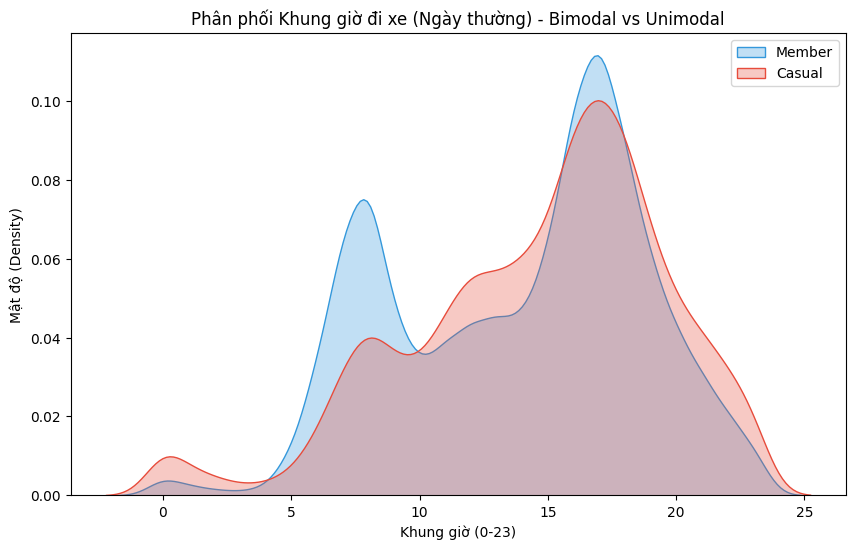

- K-S statistic: 0.08600913432185786
- p-value: 3.9008255742566655e-58
=> KẾT LUẬN: Bác bỏ H0. Phân phối thời gian (Khung giờ) của Member và Casual hoàn toàn khác biệt.
   Insight: Biểu đồ cho thấy rõ Member có 2 đỉnh (Bimodal) vào 8h và 17h (đi làm, tan ca).
   Casual chỉ có 1 đỉnh vòm dâng lên vào giữa trưa (đi chơi).


In [ ]:
city = 'divvy'

# 1. Feature Engineering: Hành trình Khép kín (Trả xe tại chỗ)
tester.analyze_circular_trips(city)

# 2. Feature Engineering: Vận tốc ước lượng qua GPS bằng Haversine
tester.analyze_speed_and_distance(city)

# 3. Nhận diện hành vi Đỉnh đôi (Bimodal) trong Giao thông Đô thị
tester.analyze_bimodal_distribution(city)


=== KIỂM ĐỊNH CHI-SQUARE: HÀNH TRÌNH KHÉP KÍN (CITIBIKE) ===
Ma trận tần số (Contingency Table):
is_circular_trip         0       1
member_casual                     
casual             8033315  369295
member            38766642  524301

- Tỷ lệ Hành trình khép kín của Casual: 4.40%
- Tỷ lệ Hành trình khép kín của Member: 1.33%

- Chi-Square statistic: 352687.30
- p-value: 0.0
=> KẾT LUẬN: Bác bỏ H0. Có sự khác biệt có ý nghĩa thống kê về tỷ lệ trả xe tại chỗ giữa 2 nhóm.
   Insight: Casual users thường thuê dạo chơi (trả chỗ cũ), trong khi Member đi làm (từ A đến B).

=== KIỂM ĐỊNH MANN-WHITNEY: VẬN TỐC DI CHUYỂN (CITIBIKE) ===
- Vận tốc trung bình Casual: 9.79 km/h
- Vận tốc trung bình Member: 11.46 km/h

- Mann-Whitney U statistic: 18994161249.5
- p-value: 0.0
=> KẾT LUẬN: Thành viên (Member) có vận tốc đi xe trung bình nhanh hơn đáng kể so với Khách vãng lai (Casual).
   Insight: Chứng minh thói quen đi làm (nhanh, gấp) vs đi chơi ngắm cảnh (chậm rãi).

=== KIỂM ĐỊNH K-S TEST: PHÂ

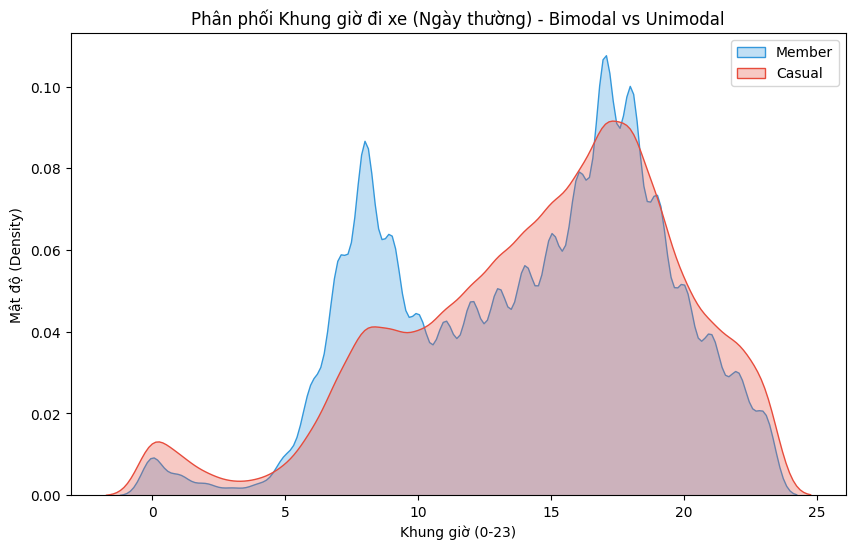

- K-S statistic: 0.07764837800662255
- p-value: 1.870568408092584e-237
=> KẾT LUẬN: Bác bỏ H0. Phân phối thời gian (Khung giờ) của Member và Casual hoàn toàn khác biệt.
   Insight: Biểu đồ cho thấy rõ Member có 2 đỉnh (Bimodal) vào 8h và 17h (đi làm, tan ca).
   Casual chỉ có 1 đỉnh vòm dâng lên vào giữa trưa (đi chơi).


In [4]:
city = 'c'

# 1. Feature Engineering: Hành trình Khép kín (Trả xe tại chỗ)
tester.analyze_circular_trips(city)

# 2. Feature Engineering: Vận tốc ước lượng qua GPS bằng Haversine
tester.analyze_speed_and_distance(city)

# 3. Nhận diện hành vi Đỉnh đôi (Bimodal) trong Giao thông Đô thị
tester.analyze_bimodal_distribution(city)


=== KIỂM ĐỊNH CHI-SQUARE: HÀNH TRÌNH KHÉP KÍN (CAPITAL) ===
Ma trận tần số (Contingency Table):
is_circular_trip        0       1
member_casual                    
casual            1718446  222572
member            4177539  624549

- Tỷ lệ Hành trình khép kín của Casual: 11.47%
- Tỷ lệ Hành trình khép kín của Member: 13.01%

- Chi-Square statistic: 2980.45
- p-value: 0.0
=> KẾT LUẬN: Bác bỏ H0. Có sự khác biệt có ý nghĩa thống kê về tỷ lệ trả xe tại chỗ giữa 2 nhóm.
   Insight: Casual users thường thuê dạo chơi (trả chỗ cũ), trong khi Member đi làm (từ A đến B).

=== KIỂM ĐỊNH MANN-WHITNEY: VẬN TỐC DI CHUYỂN (CAPITAL) ===
- Vận tốc trung bình Casual: 9.93 km/h
- Vận tốc trung bình Member: 11.85 km/h

- Mann-Whitney U statistic: 444743689.0
- p-value: 0.0
=> KẾT LUẬN: Thành viên (Member) có vận tốc đi xe trung bình nhanh hơn đáng kể so với Khách vãng lai (Casual).
   Insight: Chứng minh thói quen đi làm (nhanh, gấp) vs đi chơi ngắm cảnh (chậm rãi).

=== KIỂM ĐỊNH K-S TEST: PHÂN PHỐI Đ

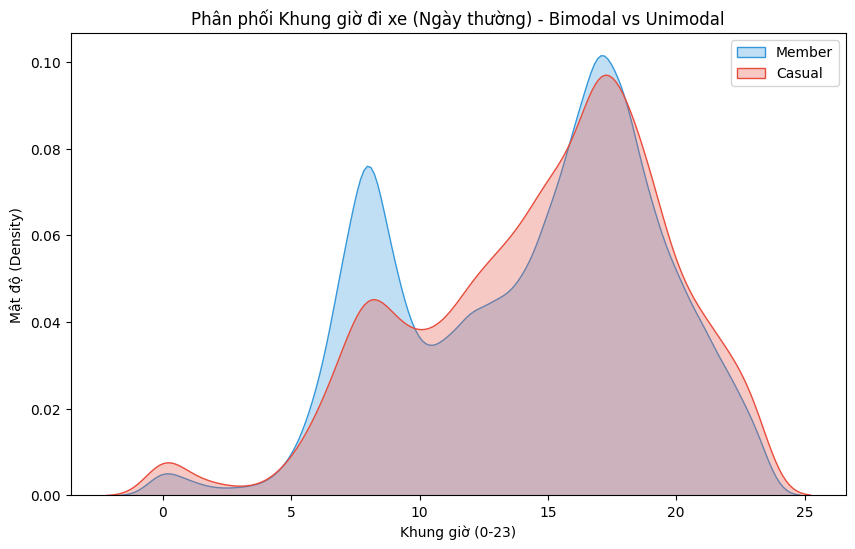

- K-S statistic: 0.0654701906596245
- p-value: 8.310919089777631e-35
=> KẾT LUẬN: Bác bỏ H0. Phân phối thời gian (Khung giờ) của Member và Casual hoàn toàn khác biệt.
   Insight: Biểu đồ cho thấy rõ Member có 2 đỉnh (Bimodal) vào 8h và 17h (đi làm, tan ca).
   Casual chỉ có 1 đỉnh vòm dâng lên vào giữa trưa (đi chơi).


In [6]:
city = 'capital'

# 1. Feature Engineering: Hành trình Khép kín (Trả xe tại chỗ)
tester.analyze_circular_trips(city)

# 2. Feature Engineering: Vận tốc ước lượng qua GPS bằng Haversine
tester.analyze_speed_and_distance(city)

# 3. Nhận diện hành vi Đỉnh đôi (Bimodal) trong Giao thông Đô thị
tester.analyze_bimodal_distribution(city)